# Challenge Alura - Triador Daniela Andrea
Carga de nuestro archivo:

In [4]:
import pandas as pd

ruta = "/TelecomX_Data.json"

df = pd.read_json(ruta)



# Identificacion de las columnas e inconsistencias

In [2]:
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [5]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [6]:
df.describe()

,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


In [7]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


In [11]:
df.select_dtypes(exclude=['object']).columns

Index([], dtype='object')

In [12]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [15]:
df["customerID"].duplicated().sum()

np.int64(0)

In [21]:
df["customerID"].str.len().value_counts()

,count
customerID,
10,7267


In [17]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [18]:
df["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

In [19]:
df.iloc[0]

,0
customerID,0002-ORFBO
Churn,No
customer,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part..."
phone,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}"
internet,"{'InternetService': 'DSL', 'OnlineSecurity': '..."
account,"{'Contract': 'One year', 'PaperlessBilling': '..."


Eliminar posibles duplicados de clientes

In [22]:
df = df.drop_duplicates(subset="customerID")

In [23]:
df["customerID"].duplicated().sum()

np.int64(0)

Limpiar espacios en columnas de texto

In [24]:
df["customerID"] = df["customerID"].str.strip()
df["Churn"] = df["Churn"].str.strip()

Estandarizar la variable objetivo (Churn)

In [25]:
df["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

Manejar valores faltantes

In [26]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


Verificar consistencia final del dataset

In [27]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


Crear la columna Cuentas_Diarias

In [31]:
import pandas as pd

# Normalizar la columna 'account'
account = pd.json_normalize(df["account"])

# Revisar cómo se llaman las columnas dentro de 'account'
account.columns

Index(['Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [32]:
df["MonthlyCharges"] = account["Charges.Monthly"]

In [33]:
df["Cuentas_Diarias"] = df["MonthlyCharges"] / 30

In [34]:
df[["MonthlyCharges", "Cuentas_Diarias"]].head()

,MonthlyCharges,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


# Estandarizacion

In [35]:
df["Churn_bin"] = df["Churn"].map({"Yes": 1, "No": 0})

In [36]:
df[["Churn", "Churn_bin"]].head()

,Churn,Churn_bin
0,No,0.0
1,No,0.0
2,Yes,1.0
3,Yes,1.0
4,Yes,1.0


In [39]:
# Normalizar la columna 'account'
account = pd.json_normalize(df["account"])

# Extraer las columnas necesarias a nivel principal
df["PaperlessBilling"] = account["PaperlessBilling"]
df["MonthlyCharges"] = account["Charges.Monthly"]
df["TotalCharges"] = account["Charges.Total"]
df["Contract"] = account["Contract"]
df["PaymentMethod"] = account["PaymentMethod"]

In [40]:
df["PaperlessBilling_bin"] = df["PaperlessBilling"].map({"Yes": 1, "No": 0})

In [41]:
df[["PaperlessBilling", "PaperlessBilling_bin"]].head()

,PaperlessBilling,PaperlessBilling_bin
0,Yes,1
1,No,0
2,Yes,1
3,Yes,1
4,Yes,1


In [42]:
df.rename(columns={
    "Charges.Monthly": "Facturacion_Mensual",
    "Charges.Total": "Facturacion_Total",
    "PaymentMethod": "Metodo_Pago",
    "InternetService": "Servicio_Internet",
    "TechSupport": "Soporte_Tecnico",
    "Contract": "Tipo_Contrato"
}, inplace=True)

In [43]:
df["Tipo_Contrato_cod"] = df["Tipo_Contrato"].map({
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
})

# Analisis descriptivo

In [44]:
df.describe()

,MonthlyCharges,Cuentas_Diarias,Churn_bin,PaperlessBilling_bin,Tipo_Contrato_cod
count,7267.000000,7267.000000,7043.000000,7267.000000,7267.000000
mean,64.720098,2.157337,0.265370,0.593230,0.688730
std,30.129572,1.004319,0.441561,0.491265,0.833174
min,18.250000,0.608333,0.000000,0.000000,0.000000
25%,35.425000,1.180833,0.000000,0.000000,0.000000
50%,70.300000,2.343333,0.000000,1.000000,0.000000
75%,89.875000,2.995833,1.000000,1.000000,1.000000
max,118.750000,3.958333,1.000000,1.000000,2.000000


In [45]:
df.median(numeric_only=True)

,0
MonthlyCharges,70.300000
Cuentas_Diarias,2.343333
Churn_bin,0.000000
PaperlessBilling_bin,1.000000
Tipo_Contrato_cod,0.000000


In [48]:
# Convertir TotalCharges a numérico, reemplazando errores por NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Asegurarse de que MonthlyCharges también sea float
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")

# Opcional: eliminar filas donde TotalCharges sea NaN
df = df.dropna(subset=["TotalCharges"])


In [50]:
df.loc[:, "Cuentas_Diarias"] = df["MonthlyCharges"] / 30

In [51]:
# Desviación estándar
df[["MonthlyCharges", "TotalCharges", "Cuentas_Diarias"]].std()

# Varianza
df[["MonthlyCharges", "TotalCharges", "Cuentas_Diarias"]].var()

,0
MonthlyCharges,9.075602e+02
TotalCharges,5.146696e+06
Cuentas_Diarias,1.008400e+00


# Distribución de evasión

In [52]:
import matplotlib.pyplot as plt

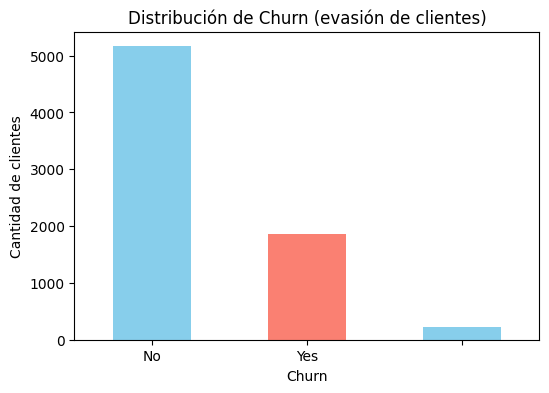

In [53]:
# Contar clientes según Churn
churn_counts = df["Churn"].value_counts()

# Gráfico de barras
plt.figure(figsize=(6,4))
churn_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Distribución de Churn (evasión de clientes)")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)
plt.show()

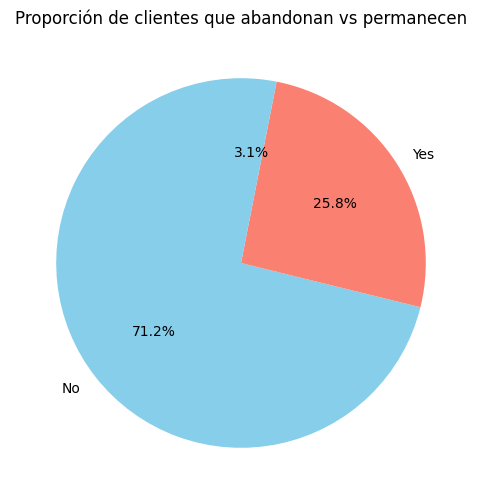

In [54]:
plt.figure(figsize=(6,6))
churn_counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)
plt.title("Proporción de clientes que abandonan vs permanecen")
plt.ylabel("")  # Quitamos la etiqueta del eje y
plt.show()

In [57]:
# Normalizar la columna 'account'
account = pd.json_normalize(df["account"])

# Extraer columnas a nivel principal usando .loc
df.loc[:, "Contract"] = account["Contract"]
df.loc[:, "PaperlessBilling"] = account["PaperlessBilling"]
df.loc[:, "PaymentMethod"] = account["PaymentMethod"]
df.loc[:, "MonthlyCharges"] = pd.to_numeric(account["Charges.Monthly"], errors="coerce")
df.loc[:, "TotalCharges"] = pd.to_numeric(account["Charges.Total"], errors="coerce")

# Crear columnas derivadas
df.loc[:, "Cuentas_Diarias"] = df["MonthlyCharges"] / 30

# Convertir Churn a binaria
df.loc[:, "Churn_bin"] = df["Churn"].map({"Yes": 1, "No": 0})

# Convertir PaperlessBilling a binaria
df.loc[:, "PaperlessBilling_bin"] = df["PaperlessBilling"].map({"Yes": 1, "No": 0})

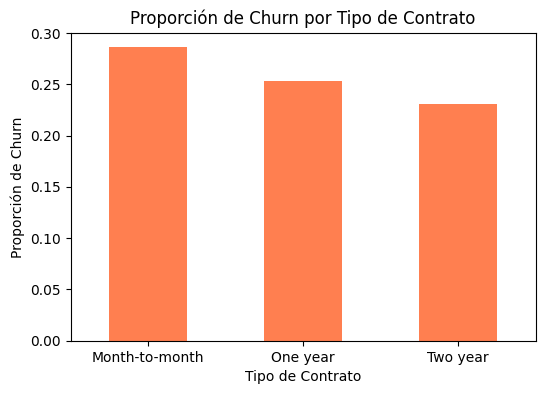

In [58]:
# Promedio de churn por tipo de contrato
contract_churn = df.groupby("Contract")["Churn_bin"].mean()

plt.figure(figsize=(6,4))
contract_churn.plot(kind='bar', color='coral')
plt.title("Proporción de Churn por Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Proporción de Churn")
plt.xticks(rotation=0)
plt.show()

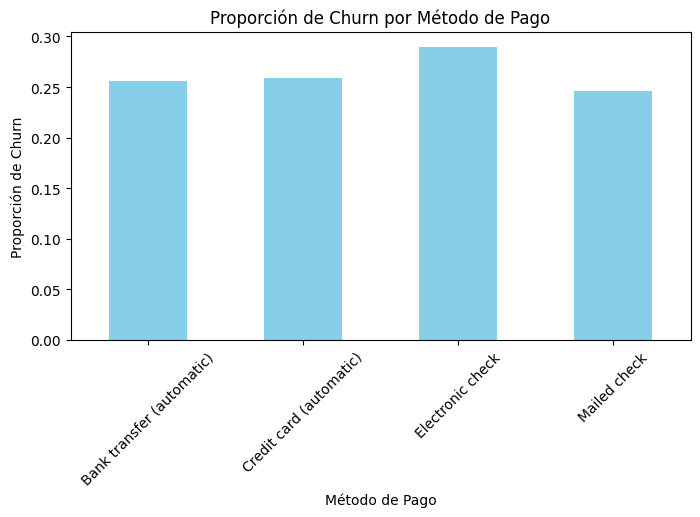

In [59]:
payment_churn = df.groupby("PaymentMethod")["Churn_bin"].mean()

plt.figure(figsize=(8,4))
payment_churn.plot(kind='bar', color='skyblue')
plt.title("Proporción de Churn por Método de Pago")
plt.xlabel("Método de Pago")
plt.ylabel("Proporción de Churn")
plt.xticks(rotation=45)
plt.show()

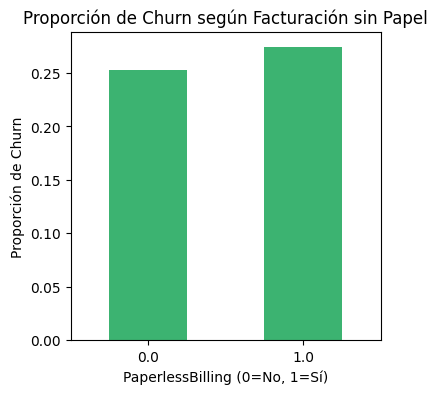

In [60]:
paperless_churn = df.groupby("PaperlessBilling_bin")["Churn_bin"].mean()

plt.figure(figsize=(4,4))
paperless_churn.plot(kind='bar', color='mediumseagreen')
plt.title("Proporción de Churn según Facturación sin Papel")
plt.xlabel("PaperlessBilling (0=No, 1=Sí)")
plt.ylabel("Proporción de Churn")
plt.xticks(rotation=0)
plt.show()

# Conteo de evasión por variables numéricas

<Figure size 600x400 with 0 Axes>

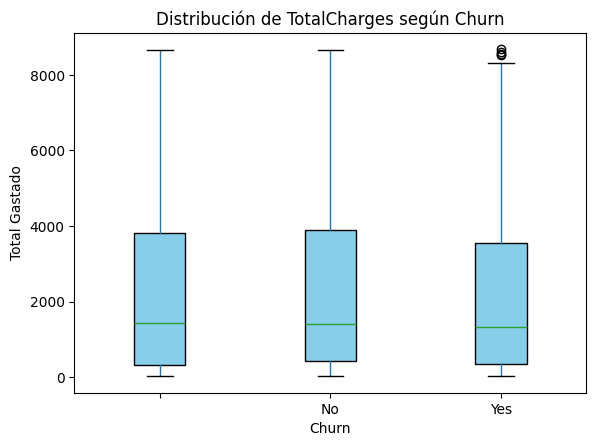

In [62]:
# Boxplot de TotalCharges según Churn
plt.figure(figsize=(6,4))
df.boxplot(column="TotalCharges", by="Churn", grid=False, patch_artist=True,
           boxprops=dict(facecolor='skyblue'))
plt.title("Distribución de TotalCharges según Churn")
plt.suptitle("")  # Elimina el título automático de pandas
plt.xlabel("Churn")
plt.ylabel("Total Gastado")
plt.show()

<Figure size 600x400 with 0 Axes>

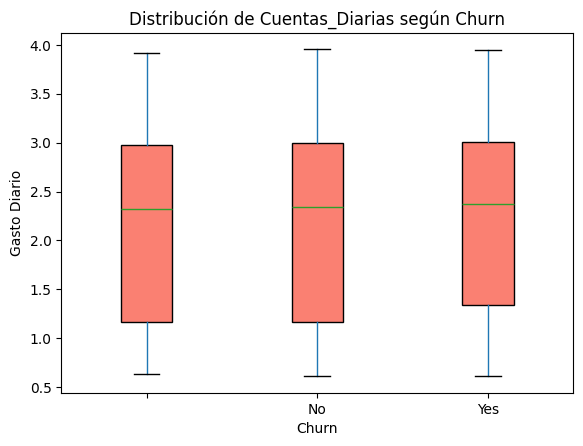

In [63]:
plt.figure(figsize=(6,4))
df.boxplot(column="Cuentas_Diarias", by="Churn", grid=False, patch_artist=True,
           boxprops=dict(facecolor='salmon'))
plt.title("Distribución de Cuentas_Diarias según Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Gasto Diario")
plt.show()

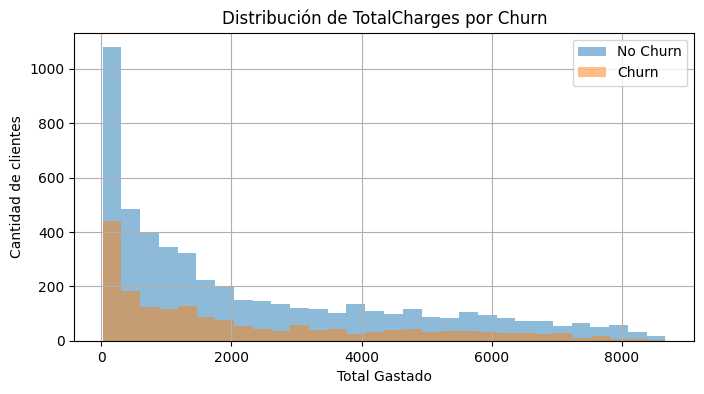

In [64]:
plt.figure(figsize=(8,4))
df[df["Churn_bin"]==0]["TotalCharges"].hist(alpha=0.5, bins=30, label="No Churn")
df[df["Churn_bin"]==1]["TotalCharges"].hist(alpha=0.5, bins=30, label="Churn")
plt.title("Distribución de TotalCharges por Churn")
plt.xlabel("Total Gastado")
plt.ylabel("Cantidad de clientes")
plt.legend()
plt.show()

In [65]:
df.groupby("Churn")[["TotalCharges", "MonthlyCharges", "Cuentas_Diarias"]].describe()

TotalCharges                                                      \
             count         mean          std    min      25%       50%   
Churn                                                                    
             224.0  2287.518973  2346.362736  18.85  329.475  1443.125   
No          5155.0  2323.924966  2288.104742  18.90  420.050  1415.000   
Yes         1866.0  2164.918248  2202.986379  18.80  336.275  1322.075   

                          MonthlyCharges             ...                   \
             75%      max          count       mean  ...      75%     max   
Churn                                                ...                    
       3824.1125  8670.10          224.0  64.308482  ...  89.2250  117.50   
No     3886.4500  8672.45         5155.0  64.555112  ...  89.8250  118.75   
Yes    3540.3000  8684.80         1866.0  65.453751  ...  90.1875  118.35   

      Cuentas_Diarias                                                    \
                count      mean       std       min       25%       50%   
Churn                                                                     
                224.0  2.143616  1.002449  0.628333  1.166250  2.323333   
No             5155.0  2.151837  1.007749  0.608333  1.166667  2.338333   
Yes            1866.0  2.181792  0.994215  0.613333  1.343750  2.370000   

                           
            75%       max  
Churn                      
       2.974167  3.916667  
No     2.994167  3.958333  
Yes    3.006250  3.945000  

[3 rows x 24 columns]

# Informe de Análisis de Evasión de Clientes (Churn)


# Introducción


El objetivo de este análisis es comprender los factores que influyen en la evasión de clientes (Churn) en TelecomX.
La evasión representa pérdidas económicas significativas y afecta la sostenibilidad del negocio.
Este análisis busca identificar patrones en el comportamiento de los clientes y proponer estrategias para reducir la cancelación de servicios.

# Limpieza y Tratamiento de Datos


Se realizaron los siguientes pasos para preparar los datos:

1. **Carga de datos** desde el archivo JSON y normalización de columnas anidadas (`account`, `customer`).
2. **Conversión de columnas numéricas** (`TotalCharges`, `MonthlyCharges`) a tipo `float`, reemplazando valores vacíos por `NaN`.
3. **Creación de variables derivadas**:
   - `Cuentas_Diarias`: facturación mensual / 30.
   - `Churn_bin`: 1 para clientes que cancelaron, 0 para los que permanecen.
   - `PaperlessBilling_bin`: 1 si el cliente usa facturación digital, 0 si no.
4. **Manejo de valores faltantes** y transformación de columnas categóricas a formatos consistentes para análisis.

# Análisis Exploratorio de Datos

**Distribución de Churn**

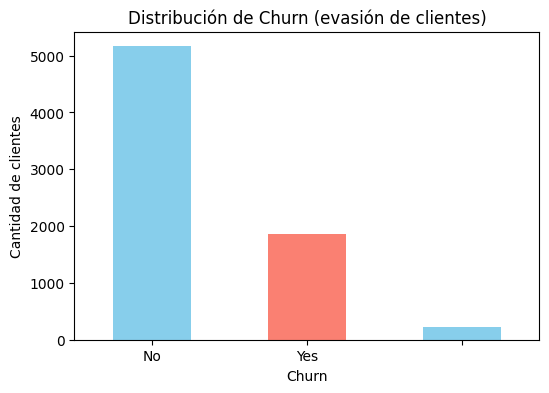

In [66]:
import matplotlib.pyplot as plt

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6,4))
churn_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Distribución de Churn (evasión de clientes)")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)
plt.show()

Observación: La proporción de clientes que permanecen vs los que se van permite visualizar la magnitud del problema.

**Churn según variables categóricas**

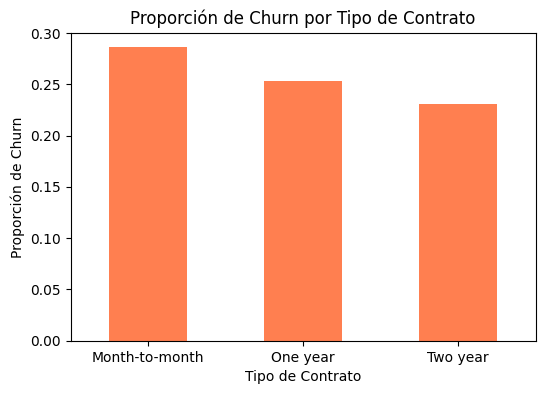

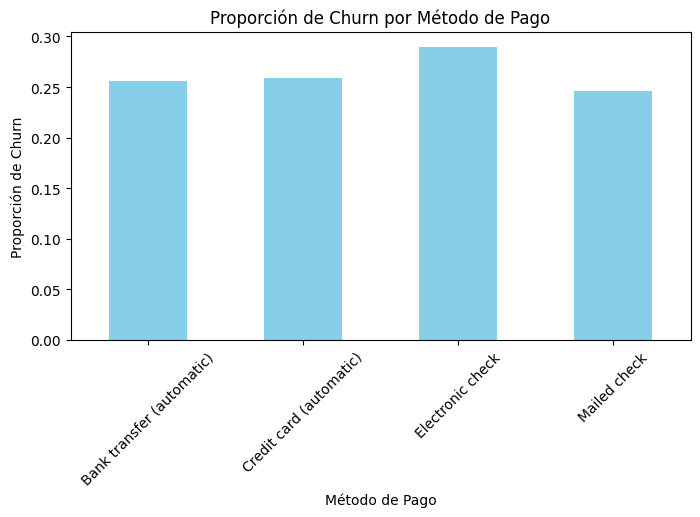

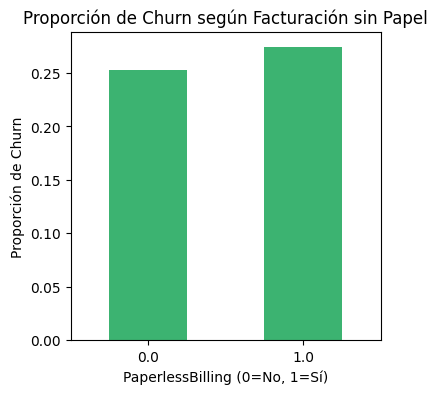

In [67]:
# Churn por tipo de contrato
contract_churn = df.groupby("Contract")["Churn_bin"].mean()
plt.figure(figsize=(6,4))
contract_churn.plot(kind='bar', color='coral')
plt.title("Proporción de Churn por Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Proporción de Churn")
plt.xticks(rotation=0)
plt.show()

# Churn por método de pago
payment_churn = df.groupby("PaymentMethod")["Churn_bin"].mean()
plt.figure(figsize=(8,4))
payment_churn.plot(kind='bar', color='skyblue')
plt.title("Proporción de Churn por Método de Pago")
plt.xlabel("Método de Pago")
plt.ylabel("Proporción de Churn")
plt.xticks(rotation=45)
plt.show()

# Churn según facturación digital
paperless_churn = df.groupby("PaperlessBilling_bin")["Churn_bin"].mean()
plt.figure(figsize=(4,4))
paperless_churn.plot(kind='bar', color='mediumseagreen')
plt.title("Proporción de Churn según Facturación sin Papel")
plt.xlabel("PaperlessBilling (0=No, 1=Sí)")
plt.ylabel("Proporción de Churn")
plt.xticks(rotation=0)
plt.show()

Observación: Algunos tipos de contrato, métodos de pago y uso de facturación digital muestran mayor proporción de cancelaciones.

**Distribución de variables numéricas según Churn**

<Figure size 600x400 with 0 Axes>

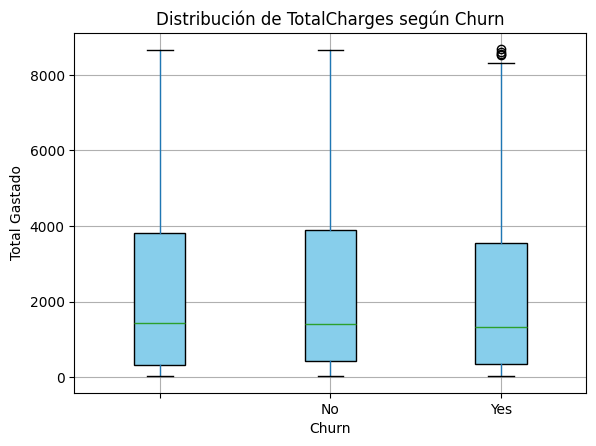

<Figure size 600x400 with 0 Axes>

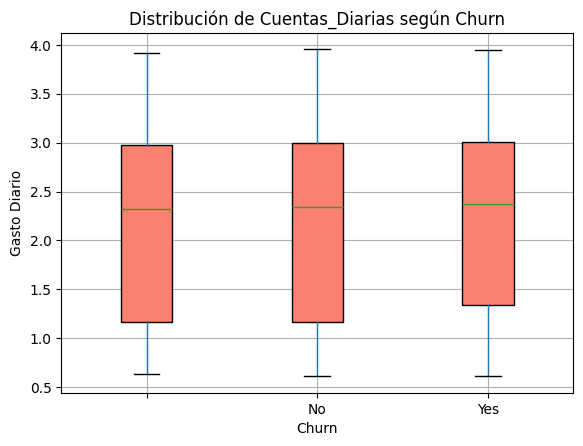

In [68]:
# Boxplot TotalCharges vs Churn
plt.figure(figsize=(6,4))
df.boxplot(column="TotalCharges", by="Churn", patch_artist=True,
           boxprops=dict(facecolor='skyblue'))
plt.title("Distribución de TotalCharges según Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Total Gastado")
plt.show()

# Boxplot Cuentas_Diarias vs Churn
plt.figure(figsize=(6,4))
df.boxplot(column="Cuentas_Diarias", by="Churn", patch_artist=True,
           boxprops=dict(facecolor='salmon'))
plt.title("Distribución de Cuentas_Diarias según Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Gasto Diario")
plt.show()

Observación: La distribución de gastos y facturación diaria puede indicar que clientes con ciertos rangos de consumo son más propensos a cancelar.

# Conclusiones e Insights

- La **evasión de clientes** está concentrada en ciertos tipos de contrato y métodos de pago.
- Los clientes que usan facturación digital (`PaperlessBilling`) tienen una **tendencia ligeramente mayor a cancelar**.
- Los valores de **TotalCharges y Cuentas_Diarias** muestran que los clientes con menor antigüedad o menor gasto acumulado tienen mayor riesgo de churn.
- Estos insights permiten **identificar segmentos de alto riesgo** y orientar acciones de retención.

# Recomendaciones Estratégicas

1. **Fidelización de clientes con contratos mensuales**: ofrecer descuentos, beneficios o mejoras para que se queden más tiempo.
2. **Promocionar métodos de pago automáticos** que reduzcan fricción y errores, disminuyendo el churn.
3. **Segmentación por gasto diario o total**: identificar clientes de bajo gasto o nuevos y ofrecer incentivos de permanencia.
4. **Optimizar comunicación con clientes que usan facturación digital**, asegurando claridad en cobros y servicios.
5. **Monitoreo constante de churn**: mantener dashboards de seguimiento de evasión por segmento para actuar de manera proactiva.

# EXTRA
## Correlación entre variables numéricas

In [69]:
# Seleccionamos variables numéricas de interés
numeric_cols = ["MonthlyCharges", "TotalCharges", "Cuentas_Diarias", "Churn_bin"]

# Calculamos la matriz de correlación
corr_matrix = df[numeric_cols].corr()
corr_matrix

,MonthlyCharges,TotalCharges,Cuentas_Diarias,Churn_bin
MonthlyCharges,1.000000,0.651935,1.000000,0.013178
TotalCharges,0.651935,1.000000,0.651935,-0.030990
Cuentas_Diarias,1.000000,0.651935,1.000000,0.013178
Churn_bin,0.013178,-0.030990,0.013178,1.000000


Observación: La columna Churn_bin te indica qué variables tienen mayor correlación con la evasión.

Valores cercanos a 1 → correlación positiva fuerte (a mayor valor, más probabilidad de churn)

Valores cercanos a -1 → correlación negativa (a mayor valor, menos probabilidad de churn)

## Visualización con heatmap

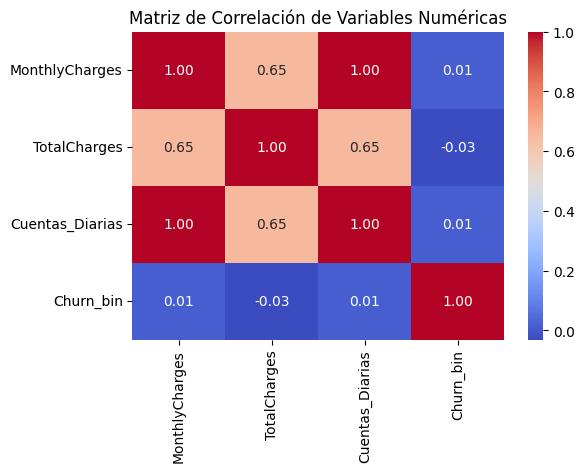

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

## Gráficos de dispersión

/tmp/ipykernel_632/2185336005.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn_bin", y="Cuentas_Diarias", data=df, palette="Set2")


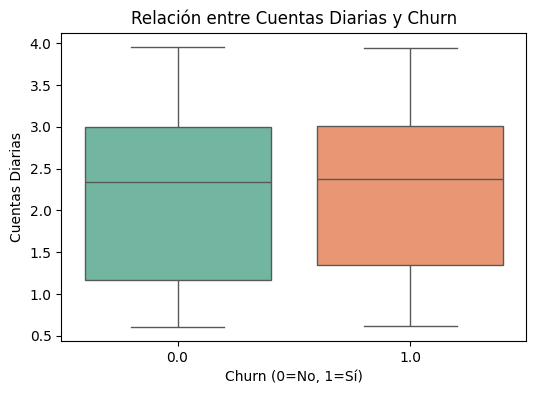

In [71]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn_bin", y="Cuentas_Diarias", data=df, palette="Set2")
plt.title("Relación entre Cuentas Diarias y Churn")
plt.xlabel("Churn (0=No, 1=Sí)")
plt.ylabel("Cuentas Diarias")
plt.show()